<a href="https://colab.research.google.com/github/AshrfCode/Data-Mining-and-Machine-Learning/blob/main/lab6_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
#import datasets
from sklearn import datasets
#matplotlib inline
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# Find the distance between vectors
def vecDist(vec1,vec2):
    vecDiff = vec1-vec2
#compute the distance ("pitagoras")
    vecSqr =  np.square(vecDiff)
    vecSum =  np.sum(vecSqr)
    return np.sqrt(vecSum)

In [ ]:
# Plot the data with colored labels
def plotData(data, labels,fNames,col1,col2,labelsType):
    #plot the titles
    plt.title("The Iris Dataset " + labelsType +  " labels")
    plt.xlabel(fNames[col1])
    plt.ylabel(fNames[col2])
    # plot the data with different color for every label and size of 50 pixels
    myPlot = plt.scatter(data[:,col1],data[:,col2],c = labels, s=50)
    plt.legend(handles=myPlot.legend_elements()[0], labels=list(set(labels)))
    plt.show()

In [ ]:
#Load Iris dataset
Iris = datasets.load_iris()
data = Iris.data
trueLabels = Iris.target+1 # true labeling
fNames = Iris.feature_names

# **PART 1**

In [ ]:
# Split the data into test and train data
trainData, testData, trainLabels, testLabels = train_test_split(
    data, trueLabels, test_size = 0.20)

# **PART 2**

In [ ]:
# Create an array to hold all our predictions
my_predictedLabels = np.zeros(testLabels.size)

# Loop over every sample in the test set
for test_idx, test_sample in enumerate(testData):

    # Array to hold distances from the current test sample to all train samples
    dist = np.zeros(trainLabels.size)

    # Calculate distance to every training sample
    for train_idx, train_sample in enumerate(trainData):
        dist[train_idx] = vecDist(test_sample, train_sample)

    # Find the index of the nearest training sample (minimum distance)
    nearest_idx = np.argmin(dist)

    # Assign the label of the nearest neighbor as our prediction
    my_predictedLabels[test_idx] = trainLabels[nearest_idx]

# **PART 3**

In [ ]:
#Find the number of errors
errors = np.sum(my_predictedLabels != testLabels)
print(f"Number of errors: {errors}")

Number of errors: 2


# **PART 4**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

#Build the confusion matrix
cm = confusion_matrix(testLabels, my_predictedLabels)
print("Confusion Matrix:\n", cm)

#Find the accuracy
acc = accuracy_score(testLabels, my_predictedLabels)
print(f"Accuracy: {acc * 100:.2f}%")

Confusion Matrix:
 [[ 9  0  0]
 [ 0  8  1]
 [ 0  1 11]]
Accuracy: 93.33%


# **PART 5**

In [ ]:


k = 1
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(trainData, trainLabels)

builtin_predictedLabels = knn.predict(testData)

print("Manual KNN predicted labels:")
print(my_predictedLabels)

print("Built-in KNN predicted labels:")
print(builtin_predictedLabels)


differences = np.sum(my_predictedLabels != builtin_predictedLabels)
print(f"Differences between custom KNN and built-in KNN: {differences}")

Manual KNN predicted labels:
[2. 3. 2. 3. 3. 1. 1. 1. 1. 3. 2. 1. 3. 3. 2. 1. 2. 3. 3. 2. 2. 3. 3. 1.
 2. 3. 1. 3. 1. 2.]
Built-in KNN predicted labels:
[2 3 2 3 3 1 1 1 1 3 2 1 3 3 2 1 2 3 3 2 2 3 3 1 2 3 1 3 1 2]
Differences between custom KNN and built-in KNN: 0


# **PART 6**

In [ ]:
flowerNames = Iris.target_names

print("\nCorrect predictions per flower type:")

for flowerType in [1, 2, 3]:
    indexes = np.where(testLabels == flowerType)[0]

    correct = np.sum(my_predictedLabels[indexes] == testLabels[indexes])
    total = len(indexes)

    print(flowerNames[flowerType - 1], "correct:", correct, "out of", total)


Correct predictions per flower type:
setosa correct: 6 out of 6
versicolor correct: 17 out of 18
virginica correct: 6 out of 6


In [ ]:
# %% knn pridict sample
# Predicted a data sample using the KNN algorithm with k=1

# take a sample from the test group and predict its label type
testI = 29
testDataI=testData[testI,:]

In [ ]:
# Find the  distance between the selected sample and all the
# samples in the training group
dist = np.zeros(trainLabels.size)
for i,trainDataI in enumerate(trainData):
    dist[i] = vecDist(testDataI,trainDataI)

In [ ]:
# find the index of the train sample with the mininum distance
# to the selected sample
predictI = np.argmin(dist)
# get the label of the found sample
predictedLabel = trainLabels[predictI]
print("our knn = 1 prediction")
print("Sample:", testI, "predicted label:", predictedLabel, "true label",testLabels[testI])

our knn = 1 prediction
Sample: 29 predicted label: 1 true label 1


In [ ]:
# Use knn build in algorithm

# choose the number of neigbors
k=1
# prepare the knn model with the given k
knn = KNeighborsClassifier(n_neighbors=k)
# Build the knn model with the given data
knn.fit(trainData, trainLabels)

KNeighborsClassifier(n_neighbors=1)

# **PART 7**

In [ ]:
# Automate the testing for k=1, 3, and 5
k_values = [1, 3, 5]
runs = 3

for k in k_values:
    accuracies = []
    for _ in range(runs):
        # Split data randomly
        trainData, testData, trainLabels, testLabels = train_test_split(data, trueLabels, test_size=0.20)

        # Train model
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(trainData, trainLabels)

        # Predict and score
        acc = accuracy_score(testLabels, knn.predict(testData))
        accuracies.append(acc)

    avg_acc = np.mean(accuracies)
    print(f"Average accuracy for k={k} over {runs} runs: {avg_acc * 100:.2f}%")

Average accuracy for k=1 over 3 runs: 94.44%
Average accuracy for k=3 over 3 runs: 97.78%
Average accuracy for k=5 over 3 runs: 93.33%


In [ ]:
# predict the given sample
predictI = knn.predict([testDataI])
print("built in knn = " + str(k) + "prediction")
print("Sample:", testI, "predicted label:", predictedLabel, "true label",testLabels[testI])

built in knn = 5prediction
Sample: 29 predicted label: 1 true label 1


In [ ]:
# predict all the data in the test grpoup
predictedLabels = knn.predict(testData)

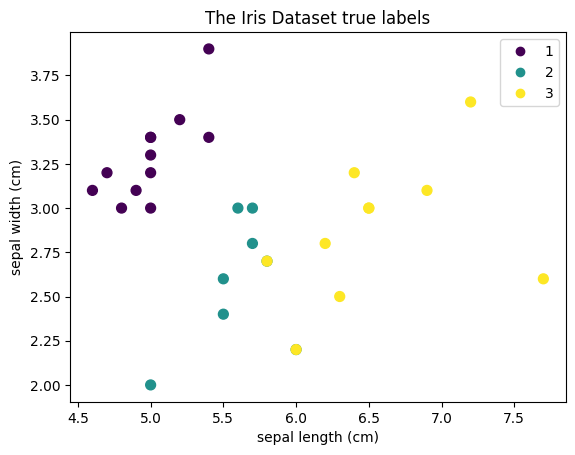

In [ ]:
# plot the samples in the test group with the true and the predicted labels
plotData(testData,testLabels,fNames,0,1,"true")

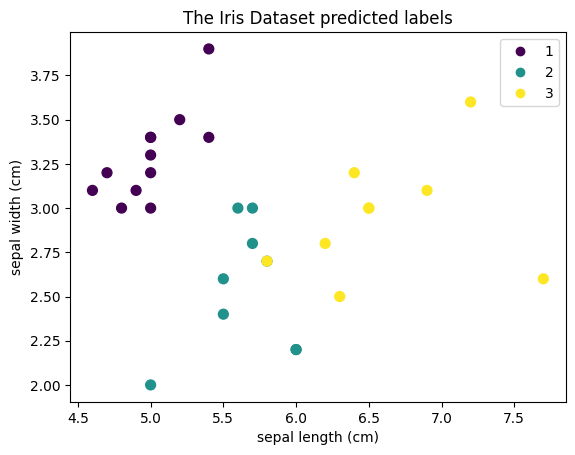

In [ ]:
plotData(testData,predictedLabels,fNames,0,1,"predicted")

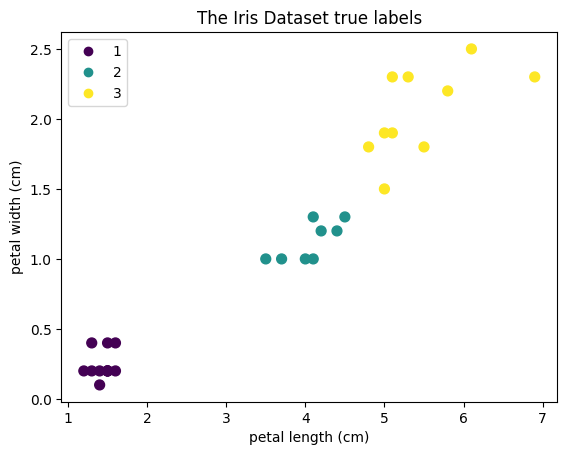

In [ ]:
plotData(testData,testLabels,fNames,2,3,"true")

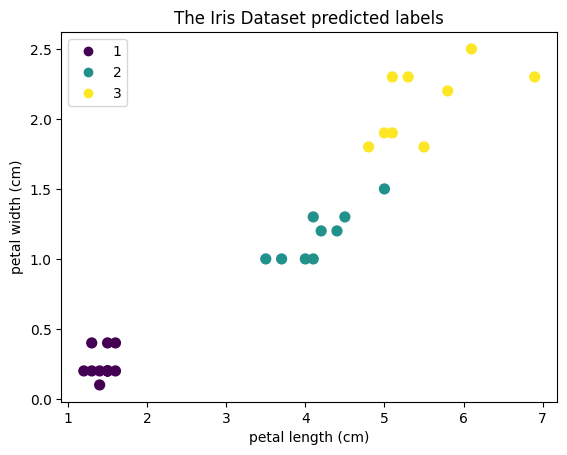

In [ ]:
plotData(testData,predictedLabels,fNames,2,3,"predicted")